# 🎯 Selección de Variables y Técnicas Estadísticas Avanzadas

Este notebook está enfocado en mostrar paso a paso diversos métodos de selección de variables y análisis estadístico, incluyendo pruebas A/B, pruebas de asociación categórica, selección de características y reducción de dimensionalidad con PCA. A lo largo del documento encontrarás:

- **Explicaciones detalladas** de cada técnica.
- **Ejemplos de uso** y casos prácticos.
- **Emojis** y subtítulos para hacer la lectura más amena y atractiva.

---

## 📊 1. AB Testing: Pruebas de Hipótesis

> 🔍 **¿Qué es un AB Testing?**  
> Es un experimento o método en el que comparamos dos versiones (A y B) para determinar cuál de ellas presenta un comportamiento más favorable.  
> **Ejemplo de caso de uso:**  
> › Una empresa de marketing digital quiere saber si el nuevo diseño de una publicidad en línea (versión B) atrae más clics que el diseño actual (versión A).


In [1]:
# 🚀 Importar librerías
import pandas as pd
import numpy as np 
import seaborn as sns 
import scipy.stats as ss 
import matplotlib.pyplot as plt 

# 📥 Cargar dataset de AB Testing
df = pd.read_csv("Dia6_AB_data.csv")

# 🔍 Vista rápida de los datos
df.head(5)

,Day,Conversion_A,Conversion_B
0,1,0.15,0.19
1,2,0.12,0.20
2,3,0.18,0.18
3,4,0.19,0.22
4,5,0.17,0.19


### 1.1 📈 Análisis Exploratorio de las Conversiones

Primero, revisamos estadísticas básicas de las conversiones para cada grupo.

In [2]:
# 🧮 Estadísticas descriptivas
df.describe()

,Day,Conversion_A,Conversion_B
count,30.000000,30.000000,30.000000
mean,15.500000,0.162000,0.193333
std,8.803408,0.036141,0.027334
min,1.000000,0.100000,0.150000
25%,8.250000,0.132500,0.180000
50%,15.500000,0.165000,0.190000
75%,22.750000,0.187500,0.200000
max,30.000000,0.230000,0.270000


**Contexto:** Queremos medir el tráfico web y comparar dos grupos A y B, a los cuales se les mostró aleatoriamente diferentes versiones de una campaña publicitaria.

C:\Users\JUNIORAOA\AppData\Local\Temp\ipykernel_13920\9373116.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Conversion_A, ax=axs[0], label="Versión A")
c:\Users\JUNIORAOA\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\JUNIORAOA\AppData\Local\Temp\ipykernel_13920\9373116.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to u

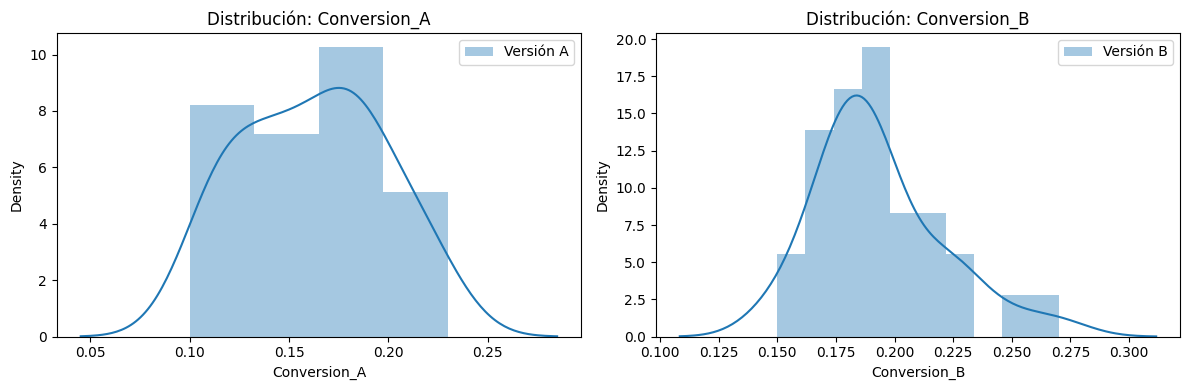

In [3]:
# 📊 Visualización de distribuciones
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

sns.distplot(df.Conversion_A, ax=axs[0], label="Versión A")
axs[0].set_title("Distribución: Conversion_A")
axs[0].legend()

sns.distplot(df.Conversion_B, ax=axs[1], label="Versión B")
axs[1].set_title("Distribución: Conversion_B")
axs[1].legend()

plt.tight_layout()
plt.show()

### 1.2 🔍 Prueba de Igualdad de Varianzas (Levene)

Antes de realizar un t-test, es fundamental verificar si las varianzas de ambos grupos son iguales. Si no lo son, debemos optar por una prueba que no asuma igualdad de varianzas.

In [4]:
from scipy.stats import levene

# 🧪 Test de Levene
stat_levene, p_levene = levene(df.Conversion_B, df.Conversion_A)
print(f"Levene statistic: {stat_levene:.4f}, p-value: {p_levene:.4f}")

Levene statistic: 5.3923, p-value: 0.0238


* 💡 **Interpretación:**

  * Si `p_levene < 0.05`, concluimos que **las varianzas son diferentes**.
  * En este caso, NO debemos usar el t-test tradicional (que asume igualdad de varianzas).

> ❗ **Resultado observado:**
> Las varianzas de `Conversion_A` y `Conversion_B` son distintas.
> 👉 ¡Debemos usar un t-test que no asuma igualdad de varianzas!

### 1.3 🧠 Prueba t para muestras independientes (varianzas desiguales)

In [5]:
# 🧮 t-test con varianzas desiguales (Welch’s t-test)
t_stat, p_val = ss.ttest_ind(df.Conversion_B, df.Conversion_A, equal_var=False)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

t-statistic: 3.7874, p-value: 0.0004


**Interpretación del p-value (con α = 0.05):**

* Si `p_val < 0.05`: existe una **diferencia estadísticamente significativa** entre ambas versiones.
* Si `p_val >= 0.05`: no se puede descartar que la diferencia se deba al azar.

> 🎉 **Conclusión:**
>
> * El p-value es menor que 0.05, por lo que **sí hay una diferencia real** entre `Conversion_A` y `Conversion_B`.
> * Como `t_stat` es positivo, significa que **`Conversion_B` tiene una media mayor que `Conversion_A`**.
> * ⇒ La nueva versión (B) convierte mejor que la versión actual (A).

## 🏷️ 2. Asociación entre Variables Categóricas: V de Cramér

> 🔍 **¿Para qué sirve la V de Cramér?**

> Mide la fuerza de asociación entre dos variables categóricas nominales. Sus valores van de 0 (sin asociación) a 1 (asociación perfecta).
> **Caso de uso:**

> Analizar cómo el género del usuario (`Gender`) se relaciona con el sistema operativo de su teléfono (`OS`).

In [6]:
# 📥 Cargar dataset de uso de teléfonos en India
df = pd.read_csv("Dia6_Phone_usage_india.csv")
df = df[["Gender", "OS"]]
df.head(10)

,Gender,OS
0,Male,Android
1,Other,iOS
2,Female,Android
3,Male,Android
4,Male,iOS
5,Male,iOS
6,Female,iOS
7,Other,iOS
8,Female,Android
9,Other,iOS


### 2.1 📊 Tabla de Contingencia y Mapa de Calor

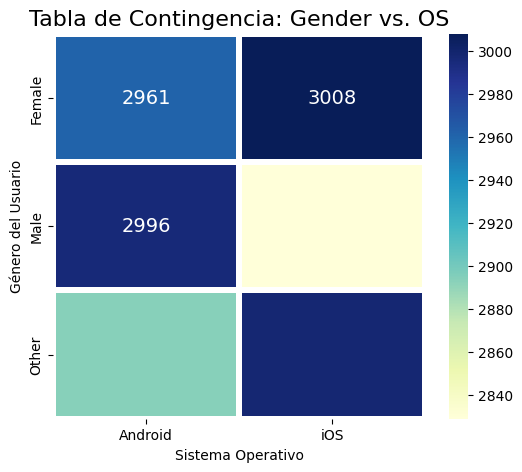

In [7]:
# 📈 Crear tabla de contingencia
t_con = pd.crosstab(df.Gender, df.OS)

# 🔥 Visualización con heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(t_con, annot=True, fmt="d", linewidths=3, linecolor="white",
            annot_kws={"size": 14}, cmap="YlGnBu")
plt.title("Tabla de Contingencia: Gender vs. OS", fontsize=16)
plt.xlabel("Sistema Operativo")
plt.ylabel("Género del Usuario")
plt.show()

### 2.2 📐 Cálculo de la V de Cramér

In [8]:
from scipy.stats.contingency import association

# 🔢 V de Cramér
v_cramer = association(t_con, method="cramer")
print(f"V de Cramér: {v_cramer:.4f}")

V de Cramér: 0.0199


**Tabla de Interpretación de la V de Cramér:**

| Valor de V de Cramér | Interpretación              |
| -------------------- | --------------------------- |
| 0.0 – 0.1            | 🔵 Muy baja o nula relación |
| 0.1 – 0.3            | 🟡 Relación débil           |
| 0.3 – 0.5            | 🟠 Relación moderada        |
| > 0.5                | 🔴 Relación fuerte o alta   |

> 👉 **Observación:**
> El valor calculado es casi cero, lo que indica **casi nula asociación** entre el género del usuario y el sistema operativo de su teléfono.

### 2.3 🤔 ¿Qué Significa?

* Las dos columnas categóricas en `t_con` **no están relacionadas**.
* No hay un patrón fuerte que conecte `Gender` con `OS`.
* **Ejemplo ilustrativo:**

  > Si tuviéramos una tabla donde una columna es “aeropuerto” y otra es “cancelado (sí/no)”, un valor bajo de V de Cramér indicaría que el aeropuerto *no influye* en si se cancela un vuelo.


### 2.4 🧑‍🏫 Consideraciones Importantes con Chi-cuadrado

Para reforzar el análisis, podemos realizar una prueba de independencia de Chi-cuadrado.


In [9]:
from scipy.stats import chi2_contingency

chi2, valor_p, grados_gl, frecuencias_esperadas = chi2_contingency(t_con)

print(f"Chi2: {chi2:.4f}")
print(f"p-value: {valor_p:.4f}")
print(f"Grados de libertad: {grados_gl}")
print("Frecuencias esperadas:\n", frecuencias_esperadas)

Chi2: 6.9791
p-value: 0.0305
Grados de libertad: 2
Frecuencias esperadas:
 [[2987.19998869 2981.80001131]
 [2915.13485243 2909.86514757]
 [2948.66515888 2943.33484112]]


> ✅ **Interpretación de resultados:**
>
> * `p-value < 0.05` ⇒ ❗ Existe relación estadística entre las variables.
> * `chi2` nos indica la magnitud de la diferencia entre las frecuencias observadas y las esperadas.
> * **Frecuencias Esperadas:** Valores que se esperarían si ambas variables fueran totalmente independientes.


## 🌟 3. Selección de Características con SelectKBest

> 🔍 **¿Por qué usar SelectKBest?**
> Permite evaluar la relevancia de cada característica (feature) de manera independiente, asignándoles un puntaje según su relación con la variable objetivo. Luego, se seleccionan las K columnas con mayor relevancia.


In [10]:
# 📥 Cargar dataset de Titanic (uso de datos de entrenamiento y prueba iguales solo a modo de ejemplo)
train = pd.read_csv("Dia3_Titanic.csv")
test = pd.read_csv("Dia3_Titanic.csv")

# 🔍 Vista rápida de los datos de entrenamiento
train.head(5)

# 🏷️ Definir variables predictoras (X) y variable objetivo (y)
X = train.drop(["Passengerid", "2urvived"], axis=1)
y = train["2urvived"]

# 📋 Anteponemos una visual para confirmar las columnas
X.head(4)

,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,...,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18
0,22.0,7.2500,0,1,0,0,0,0,0,0,...,0,0,0,0,3,0,0,2.0,0,0
1,38.0,71.2833,1,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0.0,0,0
2,26.0,7.9250,1,0,0,0,0,0,0,0,...,0,0,0,0,3,0,0,2.0,0,0
3,35.0,53.1000,1,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,2.0,0,0


### 3.1 🔄 Imputación de Valores Faltantes

In [11]:
from sklearn.impute import SimpleImputer

# 🚑 Imputar valores faltantes con la media
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Convertir de nuevo a DataFrame para facilitar la inspección
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)
X_imputed.head(5)

,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,...,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18
0,22.0,7.2500,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0
1,38.0,71.2833,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,26.0,7.9250,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0
3,35.0,53.1000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0
4,35.0,8.0500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0


### 3.2 🏅 Aplicando SelectKBest (chi2)

In [12]:
from sklearn.feature_selection import SelectKBest, chi2

# 🔢 Seleccionar todas las características y ver sus puntuaciones
sel_feat = SelectKBest(chi2, k='all').fit(X_imputed, y)
sel_bool = sel_feat.get_support()          # Máscara booleana de características seleccionadas
X_sel = X_imputed.loc[:, sel_bool]         # DataFrame con solo las variables seleccionadas
X_sel.head(5)

,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,...,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18
0,22.0,7.2500,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0
1,38.0,71.2833,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,26.0,7.9250,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0
3,35.0,53.1000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0
4,35.0,8.0500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0


**Explicación de SelectKBest:**

* Evalúa cada columna por separado usando una prueba estadística (en este caso chi-cuadrado).
* Asigna una puntuación de relevancia según la relación con la etiqueta `y`.
* Permite quedarse con las **K** columnas más importantes, facilitando la reducción de dimensiones y la interpretación del modelo.

## 🏔️ 4. Análisis de Componentes Principales (PCA)

> 🔍 **¿Qué es PCA?**
> Es una técnica de reducción de dimensionalidad que busca transformar un conjunto de variables correlacionadas en un nuevo conjunto de variables no correlacionadas (componentes principales), manteniendo la mayor varianza posible.
>
> * **Caso de uso:** Reducir la complejidad de un dataset con muchas variables, mitigando la "maldición de la dimensionalidad".
> * **Ejemplo sencillo:** Si tenemos dos características (peso y altura), en lugar de analizarlas por separado, podemos proyectarlas en un eje que combine ambas y explique la mayor parte de la varianza.


### 4.1 📥 Cargar Datos de Airbnb

In [13]:
df = pd.read_csv("Dia4_Airbnb_Open_Data.csv")
# Nos quedamos solo con dos columnas: price y number_of_reviews
df = df[["price", "number_of_reviews"]]
df.head(5)

,price,number_of_reviews
0,149,9
1,225,45
2,150,0
3,89,270
4,80,9


### 4.2 📈 Visualización Inicial


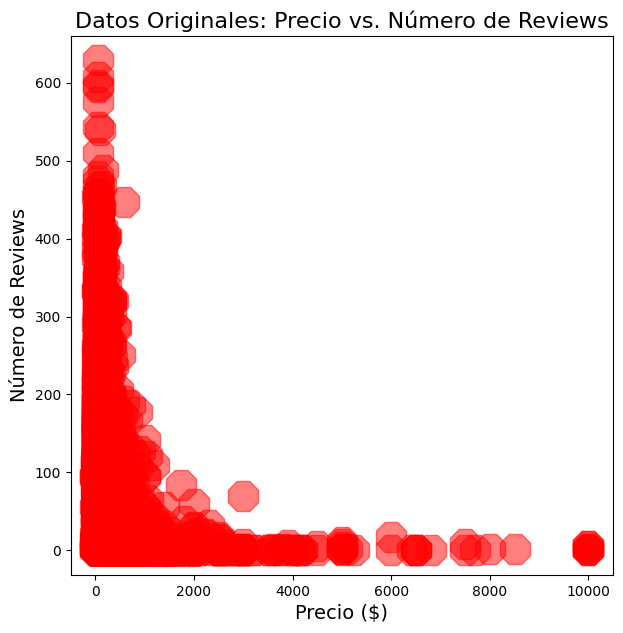

In [14]:
# 🔍 Gráfico de dispersión de los datos originales
fig = plt.figure(figsize=(7, 7))
plt.scatter(df["price"], df["number_of_reviews"], marker="8", s=550, color="red", alpha=0.5)
plt.xlabel("Precio ($)", fontsize=14)
plt.ylabel("Número de Reviews", fontsize=14)
plt.title("Datos Originales: Precio vs. Número de Reviews", fontsize=16)
plt.show()

### 4.3 🛠️ Estandarización de los Datos

Para aplicar PCA correctamente, es importante que las variables estén en la misma escala.


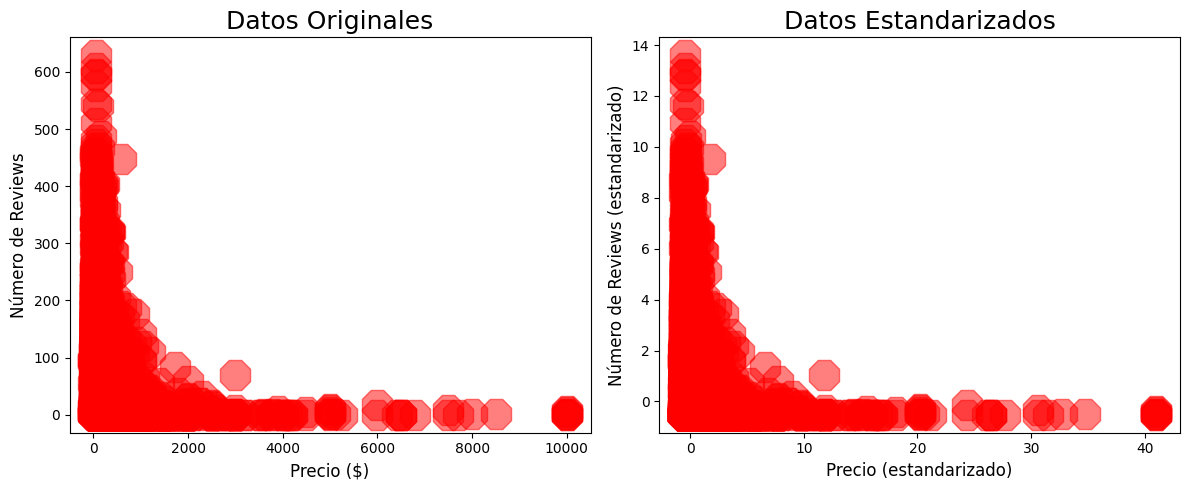

In [15]:
from sklearn.preprocessing import StandardScaler

# Crear figura con dos subplots para comparar antes y después de la estandarización
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# 🖼️ Datos Originales
ax1.set_title("Datos Originales", fontsize=18)
ax1.scatter(df["price"], df["number_of_reviews"], marker="8", s=550, color="red", alpha=0.5)
ax1.set_xlabel("Precio ($)", fontsize=12)
ax1.set_ylabel("Número de Reviews", fontsize=12)

# 🔄 Estandarizar (media=0, varianza=1)
df_std = pd.DataFrame(StandardScaler().fit_transform(df), columns=["price", "number_of_reviews"])

# 🖼️ Datos Estandarizados
ax2.set_title("Datos Estandarizados", fontsize=18)
ax2.scatter(df_std["price"], df_std["number_of_reviews"], marker="8", s=550, color="red", alpha=0.5)
ax2.set_xlabel("Precio (estandarizado)", fontsize=12)
ax2.set_ylabel("Número de Reviews (estandarizado)", fontsize=12)

plt.tight_layout()
plt.show()

### 4.4 🧮 Cálculo de Eigenvalores y Eigenvectores

Los eigenvectores determinan las direcciones principales (componentes) y los eigenvalores indican la importancia (varianza explicada) de cada componente.

In [16]:
from numpy.linalg import eig 

# 📊 Calcular matriz de covarianza y su descomposición
cov_matrix = df_std.cov()
valores, vectores = eig(cov_matrix)

vector_azul = vectores[:, 0]
vector_rojo = vectores[:, 1]

print("Eigenvector rojo:", vector_rojo, "| Eigenvalor asociado:", valores[1])
print("Eigenvector azul:", vector_azul, "| Eigenvalor asociado:", valores[0])

Eigenvector rojo: [0.70710678 0.70710678] | Eigenvalor asociado: 0.9520652450452154
Eigenvector azul: [ 0.70710678 -0.70710678] | Eigenvalor asociado: 1.0479756597692824


#### 4.4.1 📐 Visualización de los Eigenvectores

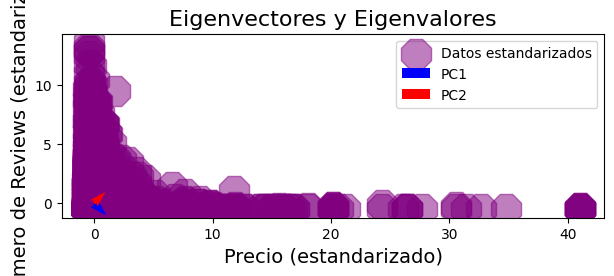

In [17]:
plt.figure(figsize=(7, 7))
plt.gca().set_aspect("equal")

# Graficar los puntos estandarizados
plt.scatter(df_std["price"], df_std["number_of_reviews"],
            marker="8", s=550, color="purple", alpha=0.5, label="Datos estandarizados")

# Dibujar eigenvectores escalados por sus eigenvalores
plt.quiver(0, 0,
           vector_azul[0]/abs(vector_azul[0]) * valores[0],
           vector_azul[1]/abs(vector_azul[1]) * valores[0],
           color="blue", angles="xy", scale_units="xy", scale=1, width=0.02, label="PC1")

plt.quiver(0, 0,
           vector_rojo[0]/abs(vector_rojo[0]) * valores[1],
           vector_rojo[1]/abs(vector_rojo[1]) * valores[1],
           color="red", angles="xy", scale_units="xy", scale=1, width=0.02, label="PC2")

plt.xlabel("Precio (estandarizado)", fontsize=14)
plt.ylabel("Número de Reviews (estandarizado)", fontsize=14)
plt.title("Eigenvectores y Eigenvalores", fontsize=16)
plt.legend()
plt.show()

### 4.5 🔄 Proyección de los Datos en el Nuevo Espacio

Ahora proyectamos los datos originales estandarizados sobre los eigenvectores para obtener las coordenadas en el espacio de componentes principales (PCs).

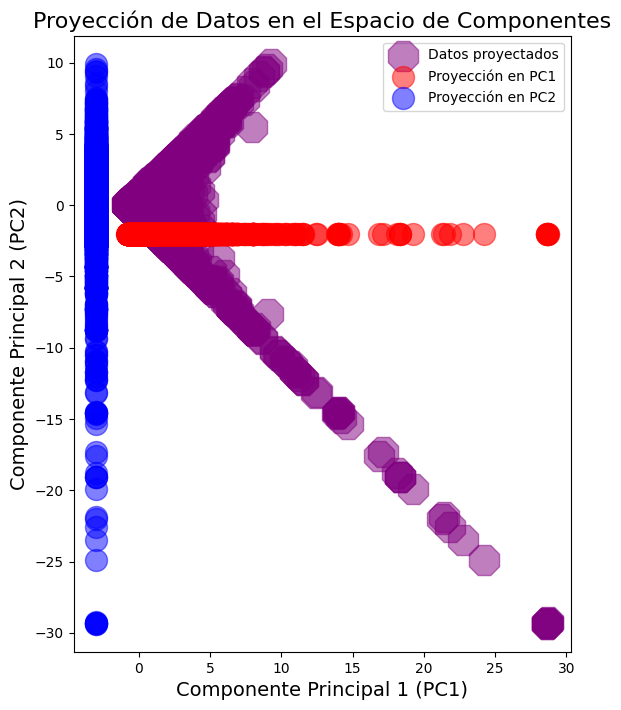

In [18]:
# 📈 Proyectar datos estandarizados en el espacio de eigenvectores
proyec = pd.DataFrame(df_std.values @ vectores.T, columns=["PC1", "PC2"])

plt.figure(figsize=(8, 8))
plt.gca().set_aspect("equal")

# Puntos originales rotados (en espacio de PCs)
plt.scatter(proyec["PC1"], proyec["PC2"], marker="8", s=550, color="purple", alpha=0.5, label="Datos proyectados")

# Proyecciones en el eje PC1 (rojo)
plt.scatter(proyec["PC1"], [-2] * len(proyec["PC1"]), s=250, color="red", alpha=0.5, label="Proyección en PC1")

# Proyecciones en el eje PC2 (azul)
plt.scatter([-3] * len(proyec["PC2"]), proyec["PC2"], s=250, color="blue", alpha=0.5, label="Proyección en PC2")

plt.xlabel("Componente Principal 1 (PC1)", fontsize=14)
plt.ylabel("Componente Principal 2 (PC2)", fontsize=14)
plt.title("Proyección de Datos en el Espacio de Componentes", fontsize=16)
plt.legend()
plt.show()

📌 **Nota:**

* Las líneas rojas y azules representan cómo cada punto se proyecta hacia su respectivo componente principal.
* La distancia a lo largo de cada eje refleja la “intensidad” de esa componente en cada observación.

### 4.6 🗂️ Selección de Componentes con `sklearn.decomposition.PCA`

Por último, usamos la implementación de PCA en Scikit-Learn para obtener de manera automática los componentes y revisar la varianza explicada.

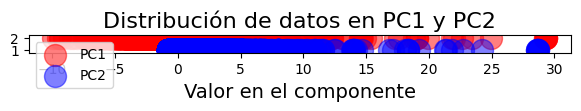

Varianza explicada por cada componente: [1.04797566 0.95206525]
Proporción de varianza explicada por cada componente: [0.52397711 0.47602289]


In [19]:
from sklearn.decomposition import PCA

# 📦 Instancia y ajuste de PCA
pca = PCA()
df_pca = pca.fit_transform(df_std)

# Visualización de los puntos en el primer y segundo componente
plt.figure(figsize=(7, 7))
plt.gca().set_aspect("equal")

plt.scatter(df_pca[:, 0], [2] * df_pca[:, 0].size, s=250, color="red", alpha=0.5, label="PC1")
plt.scatter(df_pca[:, 1], [1] * df_pca[:, 1].size, s=250, color="blue", alpha=0.5, label="PC2")

plt.ylim((0.8, 2.2))
plt.xlabel("Valor en el componente", fontsize=14)
plt.title("Distribución de datos en PC1 y PC2", fontsize=16)
plt.legend()
plt.show()

# 🧾 Imprimir varianza de cada componente
print("Varianza explicada por cada componente:", pca.explained_variance_)
print("Proporción de varianza explicada por cada componente:", pca.explained_variance_ratio_)

* **`pca.explained_variance_`**: eigenvalores que indican la cantidad de varianza capturada por cada componente.
* **`pca.explained_variance_ratio_`**: proporción de la varianza total explicada por cada componente.

> 🧐 **Interpretación:**
>
> * Si el **primer componente** explica un alto porcentaje de la varianza (por ejemplo, > 0.6), podemos quedarnos con un solo componente y reducir el dataset a 1 dimensión sin perder mucha información.
> * En nuestro caso, los valores podrían estar cercanos al 0.52 y 0.48, indicando que ambos componentes son relevantes.

Este notebook cubre desde pruebas de hipótesis A/B, evaluación de asociaciones categóricas con V de Cramér y Chi-cuadrado, hasta selección de características y reducción de dimensionalidad (PCA). Cada sección incluye explicaciones detalladas, visualizaciones y ejemplos prácticos para facilitar su comprensión y aplicación en distintos escenarios reales.